# Chapter 9. 페가소스 양자 서포트 벡터 분류기(Pegasos Quantum Support Vector Classifier)

또 다른 SVM 기반 알고리즘이 양자 커널 방법으로부터 이점을 얻는다. 여기서 우리는 Qiskit 머신 러닝에서 사용 가능한 `QSVC`의 또 다른 구현 버전인 분류 알고리즘을 소개한다. 이 분류 알고리즘은 Shalev-Shwartz 등의 논문 "Pegasos: Primal Estimated sub-GrAdient SOlver for SVM"에서 제시된 페가소스 알고리즘을 구현한다: https://home.ttic.edu/~nati/Publications/PegasosMPB.pdf.

이 알고리즘은 `scikit-learn` 패키지의 이중 최적화에 대한 대안이며, 커널 트릭(kernel trick)으로부터 이점을 얻고, 훈련 세트 크기에 무관한 훈련 복잡도를 산출한다. 따라서 `PegasosQSVC`는 충분히 큰 훈련 세트에 대해 QSVC보다 더 빠르게 훈련될 것으로 예상된다.

이 알고리즘은 `QSVC`의 직접적인 대체물로 사용될 수 있으며 일부 초매개변수 조정이 필요하다.

데이터를 생성해보자:

In [1]:
# sklearn에서 make_blobs를 사용하여 데이터셋 생성
from sklearn.datasets import make_blobs

# example dataset
features, labels = make_blobs(n_samples=20, n_features=2, centers=2, random_state=3, shuffle=True)

데이터를 전처리하여 회전 인코딩(rotation encoding)과의 호환성을 보장하고 훈련 및 테스트 데이터셋으로 분할한다.

In [2]:
# 데이터를 MinMaxScaler로 정규화하고 훈련 및 테스트 데이터로 분할
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

features = MinMaxScaler(feature_range=(0, np.pi)).fit_transform(features)

train_features, test_features, train_labels, test_labels = train_test_split(
    features, labels, train_size=15, shuffle=False
)

두 개의 특성(feature)이 데이터셋에 있으므로 큐비트(qubit)의 개수를 데이터셋의 특성 개수로 설정한다.

그다음 $\tau$를 훈련 절차 중에 수행되는 스텝의 개수로 설정한다. 이 알고리즘에는 조기 종료 기준이 없음을 주목하자. 이 알고리즘은 모든 $\tau$ 스텝을 반복한다.

마지막으로 초매개변수 $C$이다. 이것은 양수의 정규화 매개변수이다. 정규화의 강도는 $C$에 반비례한다. 더 작은 $C$는 더 작은 가중치를 유도하여 일반적으로 과적합(overfitting) 방지에 도움이 된다. 그러나 이 알고리즘의 특성상 더 큰 $C$의 경우 일부 계산 단계가 자명해진다. 따라서 더 큰 $C$는 알고리즘의 성능을 크게 향상시킨다. 데이터가 특성 공간에서 선형 분리 가능한 경우 $C$는 크게 선택되어야 한다. 분리가 완벽하지 않은 경우 $C$는 과적합을 방지하기 위해 더 작게 선택되어야 한다.

In [3]:
# 큐비트 개수, 스텝 개수, 정규화 매개변수 C 설정
# number of qubits is equal to the number of features
num_qubits = 2

# number of steps performed during the training procedure
tau = 100

# regularization parameter
C = 1000

이 알고리즘은 다음을 사용하여 실행될 것이다:

- `FidelityQuantumKernel`에서 인스턴스화된 기본 충실도(default fidelity)
- `z_feature_map`에서 생성된 양자 커널(quantum kernel)

In [4]:
# z_feature_map과 FidelityQuantumKernel을 사용하여 양자 커널 설정
from qiskit.circuit.library import z_feature_map
from qiskit_machine_learning.utils import algorithm_globals

from qiskit_machine_learning.kernels import FidelityQuantumKernel

from qiskit_machine_learning.state_fidelities import ComputeUncompute
from qiskit.primitives import StatevectorSampler as Sampler

sampler = Sampler()
fidelity = ComputeUncompute(sampler=sampler)

algorithm_globals.random_seed = 12345

feature_map = z_feature_map(feature_dimension=num_qubits, reps=1)

qkernel = FidelityQuantumKernel(fidelity=fidelity, feature_map=feature_map)

`PegasosQSVC` 구현은 `scikit-learn` 인터페이스와 호환되며 모델을 훈련하는 꽤 표준적인 방법을 가지고 있다. 생성자(constructor)에서 우리는 알고리즘의 매개변수를 전달한다. 이 경우 정규화 초매개변수 $C$와 스텝의 개수가 있다.

그다음 훈련 특성과 레이블을 `fit` 메서드에 전달하며, 이는 모델을 훈련하고 적합된 분류기를 반환한다.

그 후에, 우리는 테스트 특성과 레이블을 사용하여 모델을 평가한다.

In [5]:
# PegasosQSVC 모델을 생성하고 훈련 후 테스트 데이터로 평가
from qiskit_machine_learning.algorithms import PegasosQSVC

pegasos_qsvc = PegasosQSVC(quantum_kernel=qkernel, C=C, num_steps=tau)

# training
pegasos_qsvc.fit(train_features, train_labels)

# testing
pegasos_score = pegasos_qsvc.score(test_features, test_labels)
print(f"PegasosQSVC classification test score: {pegasos_score}")

PegasosQSVC classification test score: 1.0


시각화 목적으로 우리는 MinMaxScaler에서 적용한 최소값과 최대값을 포함하는 미리 정의된 스텝의 메시 그리드(mesh grid)를 생성한다. 또한 훈련 및 테스트 샘플의 더 나은 표현을 위해 그리드에 일부 여백을 추가한다.

In [6]:
# 시각화를 위한 메시 그리드 생성
grid_step = 0.2
margin = 0.2
grid_x, grid_y = np.meshgrid(
    np.arange(-margin, np.pi + margin, grid_step), np.arange(-margin, np.pi + margin, grid_step)
)

그리드를 모델과 호환되는 형태로 변환한다. 형태는 `(n_samples, n_features)`여야 한다.
그다음 각 그리드 포인트에 대해 레이블을 예측한다. 우리의 경우 예측된 레이블은 그리드에 색을 지정하는 데 사용될 것이다.

In [7]:
# 그리드를 모델 입력 형태로 변환하고 각 포인트에 대해 예측 수행
meshgrid_features = np.column_stack((grid_x.ravel(), grid_y.ravel()))
meshgrid_colors = pegasos_qsvc.predict(meshgrid_features)

마지막으로 우리는 모델에서 얻은 레이블/색상에 따라 그리드를 그린다. 또한 훈련 및 테스트 샘플을 그린다.

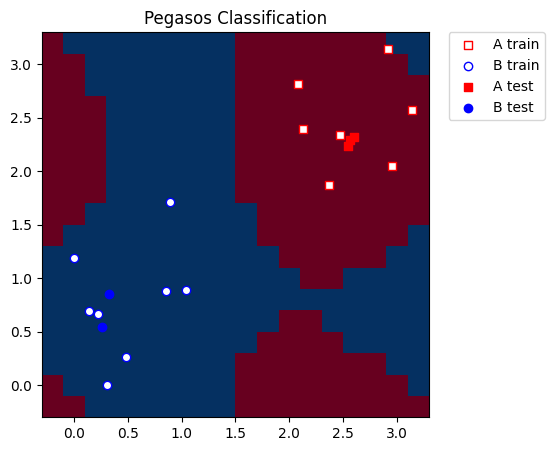

In [8]:
# matplotlib을 사용하여 분류 결과와 훈련/테스트 샘플 시각화
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 5))
meshgrid_colors = meshgrid_colors.reshape(grid_x.shape)
plt.pcolormesh(grid_x, grid_y, meshgrid_colors, cmap="RdBu", shading="auto")

plt.scatter(
    train_features[:, 0][train_labels == 0],
    train_features[:, 1][train_labels == 0],
    marker="s",
    facecolors="w",
    edgecolors="r",
    label="A train",
)
plt.scatter(
    train_features[:, 0][train_labels == 1],
    train_features[:, 1][train_labels == 1],
    marker="o",
    facecolors="w",
    edgecolors="b",
    label="B train",
)

plt.scatter(
    test_features[:, 0][test_labels == 0],
    test_features[:, 1][test_labels == 0],
    marker="s",
    facecolors="r",
    edgecolors="r",
    label="A test",
)
plt.scatter(
    test_features[:, 0][test_labels == 1],
    test_features[:, 1][test_labels == 1],
    marker="o",
    facecolors="b",
    edgecolors="b",
    label="B test",
)

plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", borderaxespad=0.0)
plt.title("Pegasos Classification")
plt.show()

In [1]:
# 버전 정보 및 저작권을 표시한다(Display version information and copyright)
import tutorial_magics

%qiskit_version_table
%qiskit_copyright